In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Admin\Desktop\PYTHON\customer_churn_list.csv')



In [3]:
df.head()

,Customer_ID,Age,Gender,Location,Tenure_Months,Subscription_Type,Monthly_Charges,Usage_Hours,Support_Tickets,Payment_Method,Number_of_Services,Churn
0,CUST100001,22,Female,Pune,3,Standard,62.06,16.1,1,Credit Card,2,No
1,CUST100002,59,Male,Hyderabad,44,Basic,26.64,8.1,1,UPI,4,No
2,CUST100003,52,Male,Hyderabad,13,Basic,24.69,9.2,3,Credit Card,4,No
3,CUST100004,41,Male,Chennai,43,Premium,102.29,39.8,4,Credit Card,2,No
4,CUST100005,40,Female,Hyderabad,34,Standard,61.71,20.2,2,UPI,1,No


In [4]:
churn_counts = df['Churn'].value_counts()

churn_counts

Churn
No     4791
Yes     209
Name: count, dtype: int64

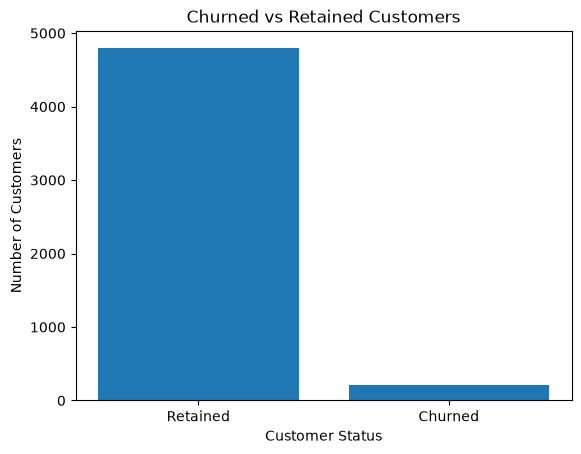

In [5]:
import matplotlib.pyplot as plt

labels = ['Retained', 'Churned']
values = [churn_counts['No'], churn_counts['Yes']]

plt.bar(labels, values)
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.title('Churned vs Retained Customers')
plt.show()

In [7]:
df['Tenure_Group'] = pd.cut(
    df['Tenure_Months'],
    bins=[0, 12, 24, 36, 48, 60],
    labels=['1-12 months', '13-24 months', '25-36 months', '37-48 months', '49-60 months']
)

In [8]:
df['Tenure_Group'].value_counts()

Tenure_Group
37-48 months    1047
49-60 months     996
25-36 months     993
1-12 months      988
13-24 months     976
Name: count, dtype: int64

In [9]:
tenure_churn = df.groupby('Tenure_Group')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

tenure_churn

Tenure_Group
1-12 months     6.477733
13-24 months    5.635246
25-36 months    4.128902
37-48 months    2.101242
49-60 months    2.710843
Name: Churn, dtype: float64

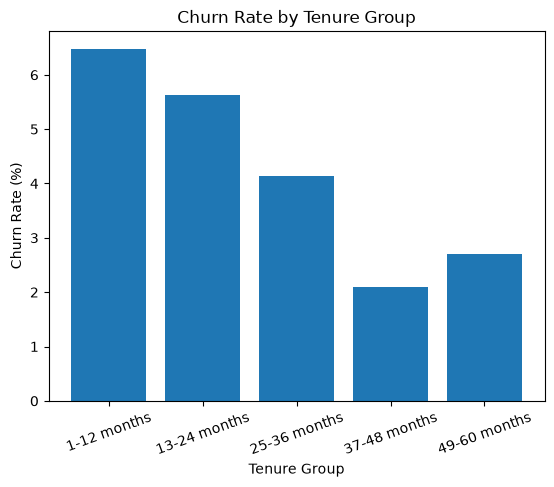

In [10]:
import matplotlib.pyplot as plt

labels = tenure_churn.index
values = tenure_churn.values

plt.bar(labels, values)
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Tenure Group')
plt.xticks(rotation=20)
plt.show()

In [12]:
df['Usage_Group'] = pd.cut(
    df['Usage_Hours'],
    bins=[0, 12, 24, 36, 48],
    labels=['Low Usage', 'Moderate Usage', 'High Usage', 'Very High Usage']
)

In [13]:
df['Usage_Group'].value_counts()

Usage_Group
Moderate Usage     2488
Low Usage          1200
High Usage         1176
Very High Usage     136
Name: count, dtype: int64

In [14]:
usage_churn = df.groupby('Usage_Group')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

usage_churn

Usage_Group
Low Usage          6.166667
Moderate Usage     3.456592
High Usage         3.826531
Very High Usage    2.941176
Name: Churn, dtype: float64

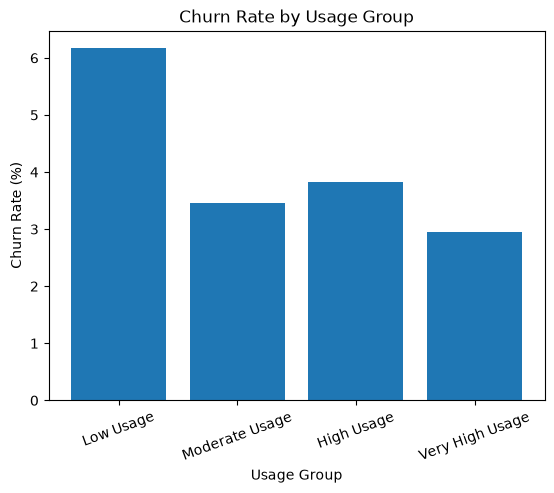

In [15]:
import matplotlib.pyplot as plt

labels = usage_churn.index
values = usage_churn.values

plt.bar(labels, values)
plt.xlabel('Usage Group')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Usage Group')
plt.xticks(rotation=20)
plt.show()

In [16]:
services_churn = df.groupby('Number_of_Services')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

services_churn

Number_of_Services
1    5.605606
2    4.684512
3    3.952569
4    3.586066
5    2.998966
Name: Churn, dtype: float64

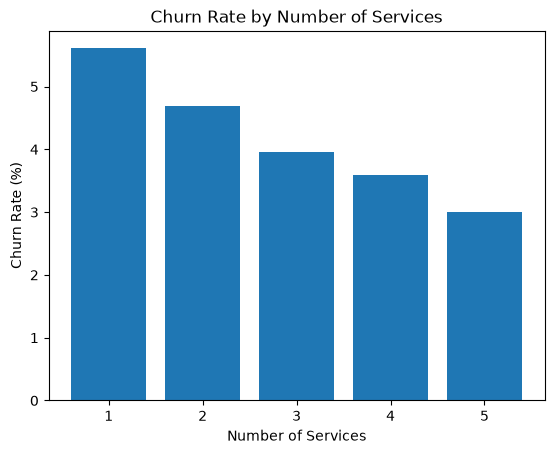

In [17]:
import matplotlib.pyplot as plt

labels = services_churn.index
values = services_churn.values

plt.bar(labels, values)
plt.xlabel('Number of Services')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Number of Services')
plt.show()

In [18]:
high_risk = df[
    (df['Tenure_Months'] <= 24) &
    (df['Usage_Group'] == 'Low Usage') &
    (df['Number_of_Services'] <= 2)
]

In [19]:
high_risk_churn_rate = (high_risk['Churn'] == 'Yes').mean() * 100

high_risk.shape[0], high_risk_churn_rate

(196, np.float64(10.714285714285714))

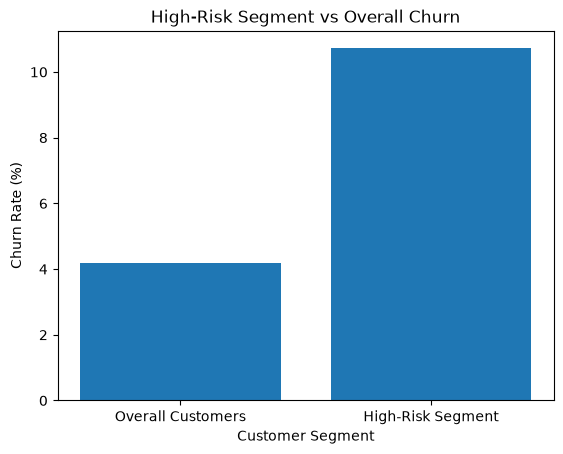

In [20]:
import matplotlib.pyplot as plt

labels = ['Overall Customers', 'High-Risk Segment']
values = [4.18, high_risk_churn_rate]

plt.bar(labels, values)
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.title('High-Risk Segment vs Overall Churn')
plt.show()

In [21]:
!pip install psycopg2-binary

   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   --------------------- ------------------ 1.6/2.9 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 9.0 MB/s  0:00:00


In [23]:
from getpass import getpass

connection_string = getpass("Paste your Neon connection string: ")

Paste your Neon connection string:  ········


In [24]:
import psycopg2

conn = psycopg2.connect(connection_string)

print("Connected to Neon PostgreSQL!")

Connected to Neon PostgreSQL!


In [25]:
conn.closed

0

In [26]:
cursor = conn.cursor()
cursor.execute("SELECT version();")
print(cursor.fetchone())

('PostgreSQL 18.6 (6569466) on aarch64-unknown-linux-gnu, compiled by gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0, 64-bit',)


In [27]:
df.shape

(5000, 14)

In [28]:
from sqlalchemy import create_engine

engine = create_engine(connection_string)

df.to_sql(
    "customer_churn",
    engine,
    if_exists="replace",
    index=False
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [31]:
churn_comparison = df.groupby('Churn')[
    ['Tenure_Months',
     'Monthly_Charges',
     'Usage_Hours',
     'Support_Tickets',
     'Number_of_Services',
     'Age']
].mean()

churn_comparison

,Tenure_Months,Monthly_Charges,Usage_Hours,Support_Tickets,Number_of_Services,Age
Churn,,,,,,
No,30.992903,54.868019,18.569192,1.694427,2.986224,43.867042
Yes,24.291866,50.619665,16.198086,1.846890,2.674641,45.258373


In [32]:
df['Churn_Numeric'] = df['Churn'].map({'No': 0, 'Yes': 1})

correlation = df[
    ['Age',
     'Tenure_Months',
     'Monthly_Charges',
     'Usage_Hours',
     'Support_Tickets',
     'Number_of_Services',
     'Churn_Numeric']
].corr()['Churn_Numeric'].sort_values(ascending=False)

correlation

Churn_Numeric         1.000000
Support_Tickets       0.023139
Age                   0.018157
Monthly_Charges      -0.032510
Number_of_Services   -0.044355
Usage_Hours          -0.053852
Tenure_Months        -0.077583
Name: Churn_Numeric, dtype: float64

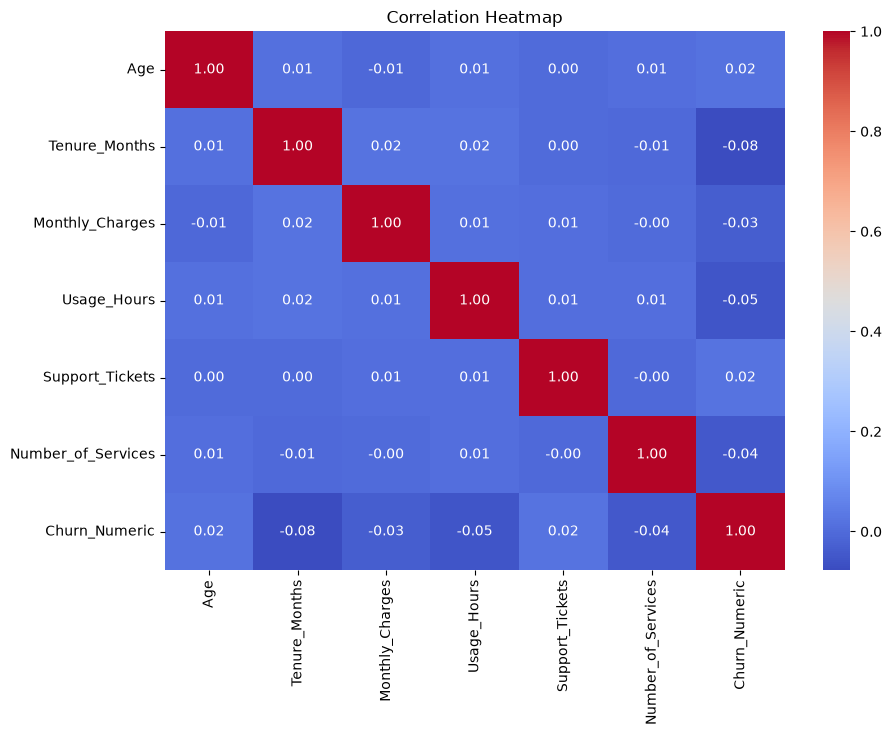

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[
        ['Age',
         'Tenure_Months',
         'Monthly_Charges',
         'Usage_Hours',
         'Support_Tickets',
         'Number_of_Services',
         'Churn_Numeric']
    ].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [35]:
subscription_churn = (
    df.groupby('Subscription_Type')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
)

subscription_churn

Subscription_Type
Basic       5.283381
Premium     3.564356
Standard    3.301887
Name: Churn, dtype: float64

In [37]:
location_churn = (
    df.groupby('Location')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
)

location_churn

Location
Delhi        5.528455
Pune         5.279503
Bengaluru    5.073650
Nagpur       4.870130
Mumbai       3.616352
Nashik       3.204047
Chennai      3.030303
Hyderabad    2.880000
Name: Churn, dtype: float64

In [38]:
payment_churn = (
    df.groupby('Payment_Method')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
)

payment_churn

Payment_Method
Credit Card       4.811251
Bank Transfer     4.488079
UPI               4.096386
Digital Wallet    3.934426
Debit Card        3.422757
Name: Churn, dtype: float64

In [39]:
powerbi_df = df[
    [
        'Customer_ID',
        'Age',
        'Gender',
        'Location',
        'Tenure_Months',
        'Subscription_Type',
        'Monthly_Charges',
        'Usage_Hours',
        'Support_Tickets',
        'Payment_Method',
        'Number_of_Services',
        'Churn'
    ]
].copy()

In [40]:
powerbi_df.shape

(5000, 12)

In [41]:
powerbi_df.to_csv(
    r'C:\Users\Admin\Desktop\PYTHON\customer_churn_powerbi.csv',
    index=False
)

In [42]:
powerbi_df.shape

(5000, 12)

In [43]:
powerbi_df.to_csv(
    r'C:\Users\Admin\Desktop\PYTHON\customer_churn_powerbi.csv',
    index=False
)

In [44]:
powerbi_df.columns


Index(['Customer_ID', 'Age', 'Gender', 'Location', 'Tenure_Months',
       'Subscription_Type', 'Monthly_Charges', 'Usage_Hours',
       'Support_Tickets', 'Payment_Method', 'Number_of_Services', 'Churn'],
      dtype='str')

In [45]:
powerbi_df['Churn'].value_counts()

Churn
No     4791
Yes     209
Name: count, dtype: int64

In [46]:
X = powerbi_df.drop('Churn', axis=1)
y = powerbi_df['Churn']

In [47]:
X = pd.get_dummies(X, drop_first=True)

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [50]:
y_pred = model.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.958

Classification Report:

              precision    recall  f1-score   support

          No       0.96      1.00      0.98       958
         Yes       0.00      0.00      0.00        42

    accuracy                           0.96      1000
   macro avg       0.48      0.50      0.49      1000
weighted avg       0.92      0.96      0.94      1000



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [55]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.942

Classification Report:

              precision    recall  f1-score   support

          No       0.96      0.98      0.97       958
         Yes       0.10      0.05      0.06        42

    accuracy                           0.94      1000
   macro avg       0.53      0.51      0.52      1000
weighted avg       0.92      0.94      0.93      1000



In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    max_depth=10
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [57]:
rf_pred = rf_model.predict(X_test)

In [58]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Accuracy: 0.862

Classification Report:

              precision    recall  f1-score   support

          No       0.96      0.89      0.93       958
         Yes       0.09      0.26      0.14        42

    accuracy                           0.86      1000
   macro avg       0.53      0.58      0.53      1000
weighted avg       0.93      0.86      0.89      1000



In [59]:
predicted_churn = model.predict(X)

powerbi_df['Predicted_Churn'] = predicted_churn

In [60]:
powerbi_df['Predicted_Churn'].value_counts()

Predicted_Churn
No     4800
Yes     200
Name: count, dtype: int64

In [61]:
pd.crosstab(
    powerbi_df['Churn'],
    powerbi_df['Predicted_Churn'],
    rownames=['Actual'],
    colnames=['Predicted']
)

Predicted,No,Yes
Actual,,
No,4760,31
Yes,40,169


In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(powerbi_df['Churn'], powerbi_df['Predicted_Churn']))
print("Precision:", precision_score(powerbi_df['Churn'], powerbi_df['Predicted_Churn'], pos_label='Yes'))
print("Recall:", recall_score(powerbi_df['Churn'], powerbi_df['Predicted_Churn'], pos_label='Yes'))
print("F1 Score:", f1_score(powerbi_df['Churn'], powerbi_df['Predicted_Churn'], pos_label='Yes'))

Accuracy: 0.9858
Precision: 0.845
Recall: 0.8086124401913876
F1 Score: 0.8264058679706602
